In [ ]:
# Iván Andrés Trujillo Abella
# ivantrujillo1229@gmail.com
# visit ai-page.readthedocs.io

In [ ]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Price discrimination
unpaired - t test.

put your significance level.

# Hypothesis

$$ H_{0} : \mu_{nurse} = \mu_{doctor}$$
$$ H_{a} : \mu_{nurse} \neq \mu_{doctor}$$


# Assumptions
* Independent observations between groups (study design)
* Normal distributed varible in each group
* Ratio or interval interest variable
* Equal variance in both groups


In [ ]:
url_barbies_prices = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/barbies_prices.csv"
df_barbies_prices = pd.read_csv(url_barbies_prices)

In [ ]:
df_barbies_prices.tail()

,price,job
255,92070.607246,Nurse
256,69357.169398,Nurse
257,88994.797892,Nurse
258,92800.242596,Nurse
259,71372.931376,Nurse


In [ ]:
df_barbies_prices['job'].value_counts()

,count
job,
Doctor,130
Nurse,130


<Axes: xlabel='job', ylabel='price'>

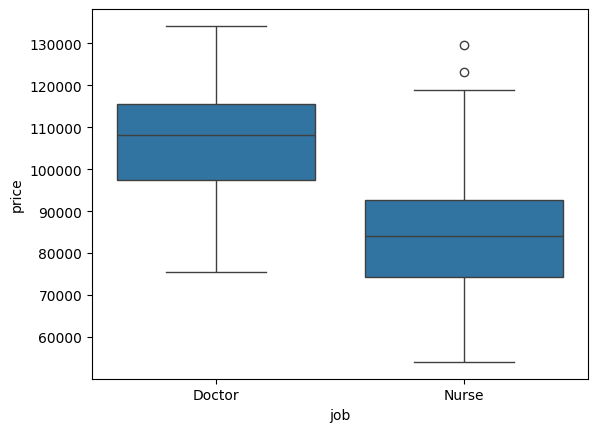

In [ ]:
sns.boxplot(data = df_barbies_prices, x ='job', y='price')

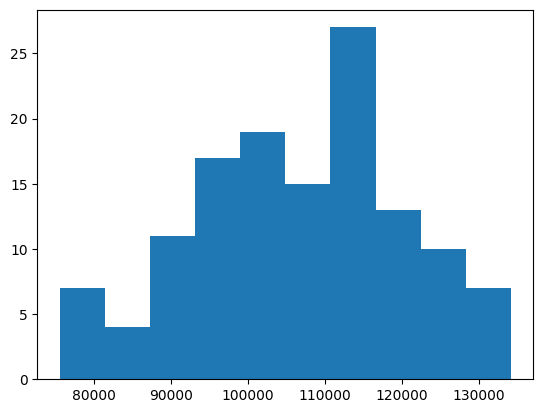

In [ ]:
plt.hist(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price']);

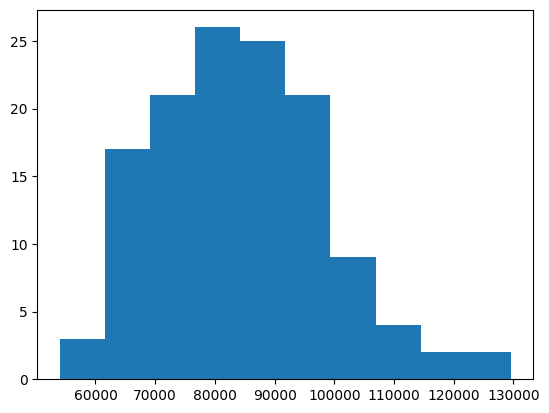

In [ ]:
plt.hist(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price']);

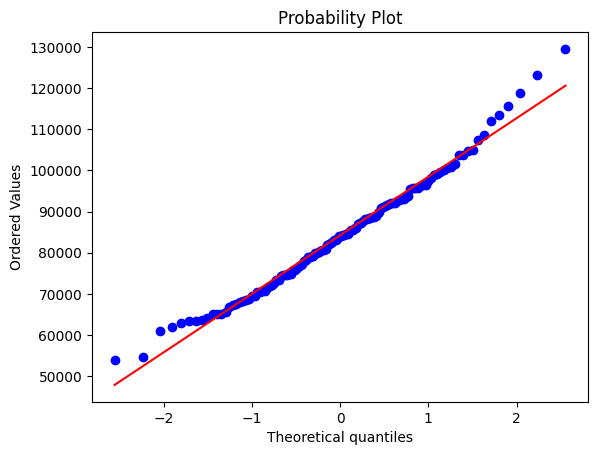

In [ ]:
# QQ-plot
scipy.stats.probplot(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'],
                     dist="norm", plot= plt);

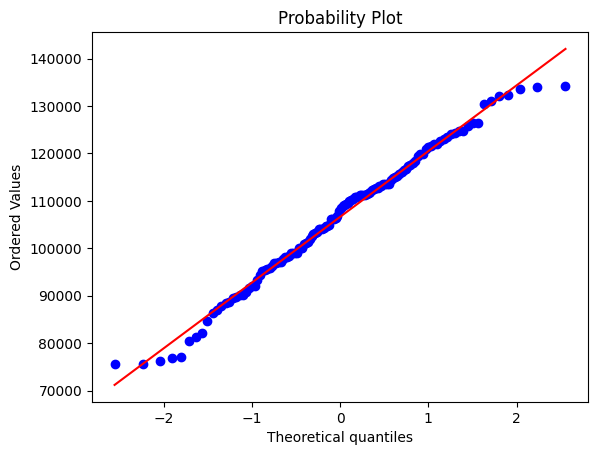

In [ ]:
scipy.stats.probplot(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price'], dist="norm", plot= plt);

# Shapiro wilk normality-test

$$ H_{0} : x \sim N (Normal)$$
$$ H_{a} : x \not\sim N (noNormal) $$

In [ ]:
# Shapiro wilk
print(scipy.stats.shapiro(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price']).pvalue)
print(scipy.stats.shapiro(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price']).pvalue)
# to accept normality then get a P-value higher than your significan level
# We meet all asumptions therefore T-test is valid.

0.22088205153326246
0.13534945960358996


# Levene test (check equal variances)

 $$ H_{0} : \sigma_{nurse}  = \sigma_{doctor} $$
 $$ H_{a}: \sigma_{nurse} \neq \sigma_{doctor}$$

In [ ]:
# We need guaranted about the inference validity, then we need check the assumptions!
# in a practical sense, the verification of assumptions is first!
scipy.stats.levene(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price'],
                   df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'],
                   center='mean' ).pvalue
# important understand the following put center='mean' assuming that data is normally distributed
# center ='median'  uses brown forysthe is mos robust to no-normally distributed data  used in skewed data.
# What said p val?
# if (p-value > alpha) -> Fail to reject -> homocedasticity (equal variances)
# leven is applicable to more than two groups.
# given that P>0.05 then the assumption is met.

np.float64(0.9636360680617037)

In [ ]:
# si ese valor ni siquiera es del 5% entonces rechacve la hipótesis

# Hypothesis t-test

$$ H_{0} : \mu_{nurse} = \mu_{doctor}$$
$$ H_{a} : \mu_{nurse} \neq \mu_{doctor}$$



In [ ]:
# applying the t-test-ind (independent), give an example of pair data or non-independent.
scipy.stats.ttest_ind(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price'],
                      df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'], equal_var=True ).pvalue
# reject null hypothesis!
# Doctor barbies are more expensive than nurse barbies
# take in mind if you uses not equal variances the is uses Welch test is more reliable than
# t-tes with unequal variances.

np.float64(9.280877211802336e-30)

# Time to work!
Is a study about mobility!.

<Axes: xlabel='transport', ylabel='time_to_work'>

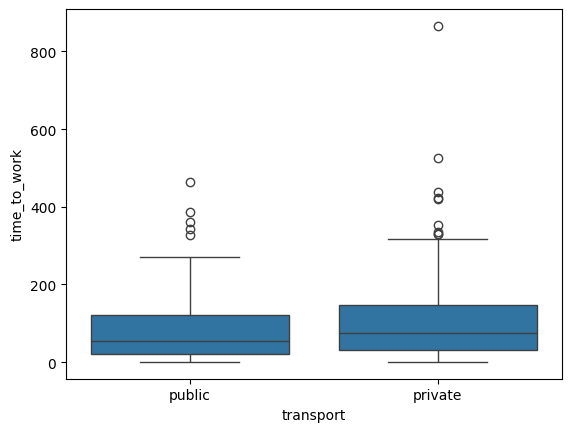

In [ ]:
url_to_work = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/time_to_work.csv"
df_to_work = pd.read_csv(url_to_work)
sns.boxplot(data = df_to_work, x = 'transport', y='time_to_work')

In [ ]:
# Assumptions
public_time = df_to_work[df_to_work['transport']=='public']['time_to_work']
private_time = df_to_work[df_to_work['transport']=='private']['time_to_work']

In [ ]:
print(scipy.stats.shapiro(public_time).pvalue) # normal?
print(scipy.stats.shapiro(private_time).pvalue) # normal?
print(scipy.stats.levene(public_time, private_time, center='median').pvalue) # homocedasticity?
# T-test not is appropiate!

4.176169215835522e-15
5.3010065290148604e-17
0.009202101424419911


In [ ]:
# if data not have equal variance then uses:
#t_stat, p = scipy.stats.ttest_ind(group1, group2, equal_var=False)

In [ ]:
# Kruskall-wallis test
# wilconxon - sum rank test!

In [ ]:
# Uses transformations
# log-tansformation
# square root - transformation
# box-cox transformation